In [1]:
# ==============================
# Import Required Libraries
# ==============================

import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import xgboost as xgb

# Save Model
import joblib

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Read Dataset

df = pd.read_csv("../dataset/train.csv")

df.head()

,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,0,5,8,5,8,6,4,4,3,3,...,5,3,3,5,4,7,5,7,3,0.445
1,1,6,7,4,4,8,8,3,5,4,...,7,2,0,3,5,3,3,4,3,0.450
2,2,6,5,6,7,3,7,1,5,4,...,7,3,7,5,6,8,2,3,3,0.530
3,3,3,4,6,5,4,8,4,7,6,...,2,4,7,4,4,6,5,7,5,0.535
4,4,5,3,2,6,4,4,3,3,3,...,2,2,6,6,4,1,2,3,5,0.415


In [3]:
print("Dataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nData Types")
print(df.dtypes)

print("\nDataset Information")
df.info()

Dataset Shape
(1117957, 22)

Column Names
Index(['id', 'MonsoonIntensity', 'TopographyDrainage', 'RiverManagement',
       'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality',
       'Siltation', 'AgriculturalPractices', 'Encroachments',
       'IneffectiveDisasterPreparedness', 'DrainageSystems',
       'CoastalVulnerability', 'Landslides', 'Watersheds',
       'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss',
       'InadequatePlanning', 'PoliticalFactors', 'FloodProbability'],
      dtype='object')

Data Types
id                                   int64
MonsoonIntensity                     int64
TopographyDrainage                   int64
RiverManagement                      int64
Deforestation                        int64
Urbanization                         int64
ClimateChange                        int64
DamsQuality                          int64
Siltation                            int64
AgriculturalPractices                int64
Encroachments           

In [4]:
df.isnull().sum()

id                                 0
MonsoonIntensity                   0
TopographyDrainage                 0
RiverManagement                    0
Deforestation                      0
Urbanization                       0
ClimateChange                      0
DamsQuality                        0
Siltation                          0
AgriculturalPractices              0
Encroachments                      0
IneffectiveDisasterPreparedness    0
DrainageSystems                    0
CoastalVulnerability               0
Landslides                         0
Watersheds                         0
DeterioratingInfrastructure        0
PopulationScore                    0
WetlandLoss                        0
InadequatePlanning                 0
PoliticalFactors                   0
FloodProbability                   0
dtype: int64

In [5]:
df.describe()

,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
count,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,...,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06
mean,5.589780e+05,4.921450e+00,4.926671e+00,4.955322e+00,4.942240e+00,4.942517e+00,4.934093e+00,4.955878e+00,4.927791e+00,4.942619e+00,...,4.946893e+00,4.953999e+00,4.931376e+00,4.929032e+00,4.925907e+00,4.927520e+00,4.950859e+00,4.940587e+00,4.939004e+00,5.044803e-01
std,3.227265e+05,2.056387e+00,2.093879e+00,2.072186e+00,2.051689e+00,2.083391e+00,2.057742e+00,2.083063e+00,2.065992e+00,2.068545e+00,...,2.072333e+00,2.088899e+00,2.078287e+00,2.082395e+00,2.064813e+00,2.074176e+00,2.068696e+00,2.081123e+00,2.090350e+00,5.102610e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.850000e-01
25%,2.794890e+05,3.000000e+00,3.000000e+00,4.000000e+00,4.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.000000e+00,3.000000e+00,...,4.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.000000e+00,3.000000e+00,4.700000e-01
50%,5.589780e+05,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,...,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.050000e-01
75%,8.384670e+05,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,...,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,5.400000e-01
max,1.117956e+06,1.600000e+01,1.800000e+01,1.600000e+01,1.700000e+01,1.700000e+01,1.700000e+01,1.600000e+01,1.600000e+01,1.600000e+01,...,1.700000e+01,1.700000e+01,1.600000e+01,1.600000e+01,1.700000e+01,1.800000e+01,1.900000e+01,1.600000e+01,1.600000e+01,7.250000e-01


In [6]:
df.duplicated().sum()

0

In [7]:
df["FloodProbability"].describe()

count    1.117957e+06
mean     5.044803e-01
std      5.102610e-02
min      2.850000e-01
25%      4.700000e-01
50%      5.050000e-01
75%      5.400000e-01
max      7.250000e-01
Name: FloodProbability, dtype: float64

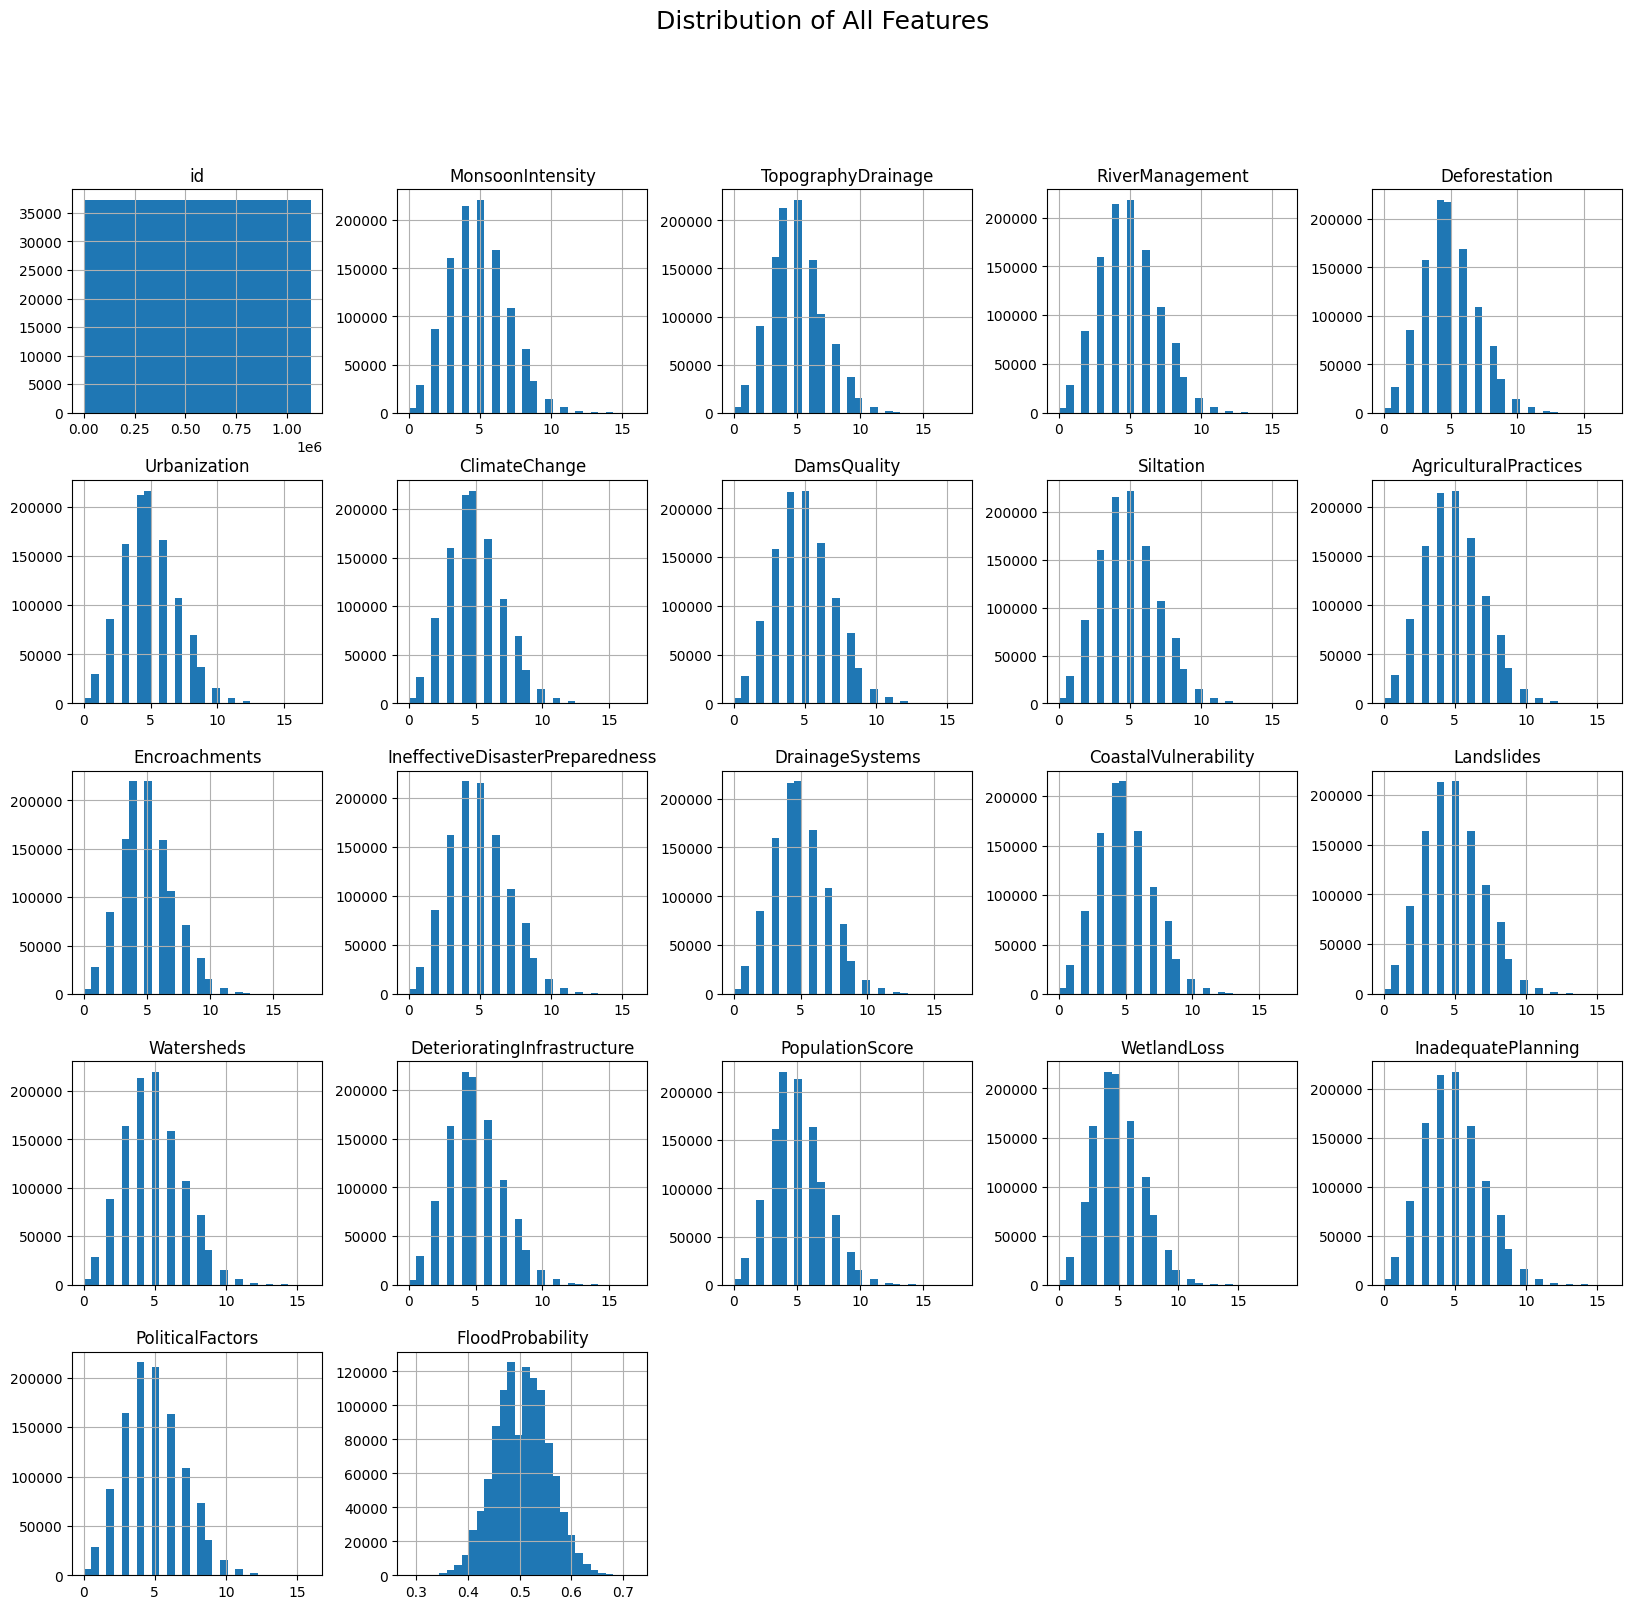

In [8]:
# Histogram of all numerical features

df.hist(figsize=(20,18), bins=30)

plt.suptitle("Distribution of All Features", fontsize=18)

plt.show()

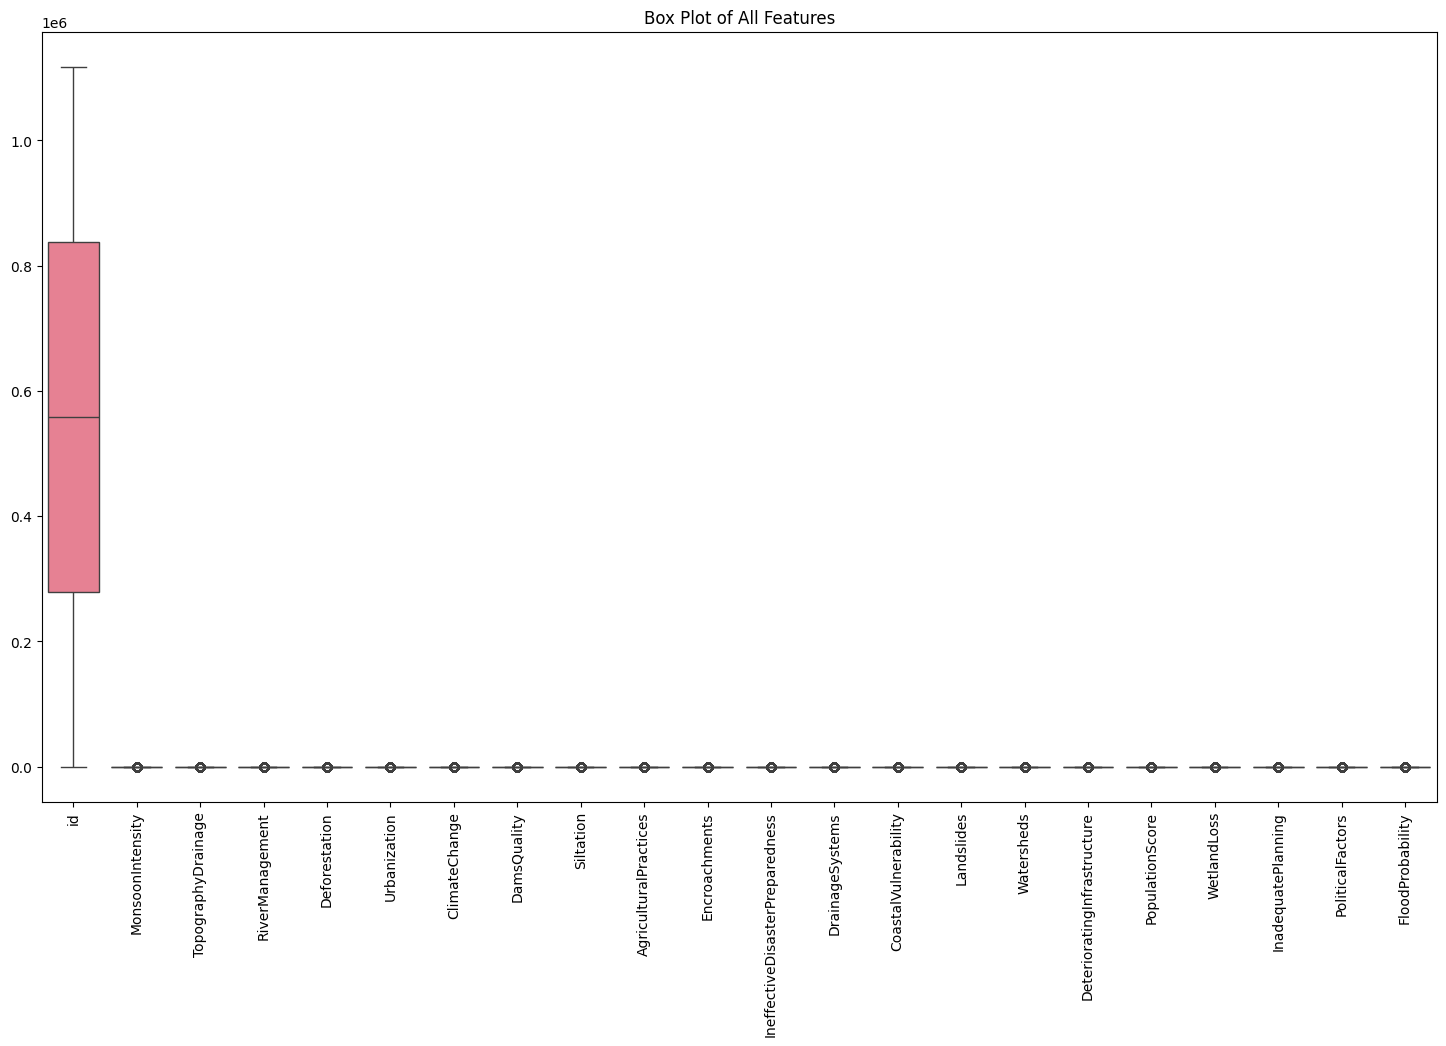

In [9]:
plt.figure(figsize=(18,10))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.title("Box Plot of All Features")

plt.show()

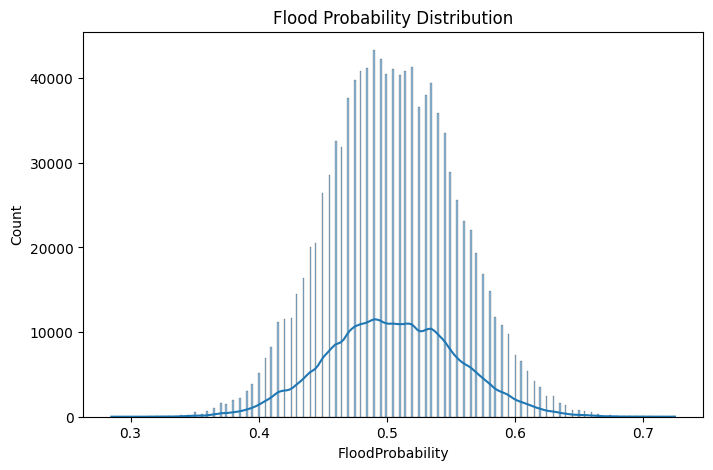

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df["FloodProbability"], kde=True)

plt.title("Flood Probability Distribution")

plt.show()

In [11]:
missing = df.isnull().sum()

print(missing)

id                                 0
MonsoonIntensity                   0
TopographyDrainage                 0
RiverManagement                    0
Deforestation                      0
Urbanization                       0
ClimateChange                      0
DamsQuality                        0
Siltation                          0
AgriculturalPractices              0
Encroachments                      0
IneffectiveDisasterPreparedness    0
DrainageSystems                    0
CoastalVulnerability               0
Landslides                         0
Watersheds                         0
DeterioratingInfrastructure        0
PopulationScore                    0
WetlandLoss                        0
InadequatePlanning                 0
PoliticalFactors                   0
FloodProbability                   0
dtype: int64


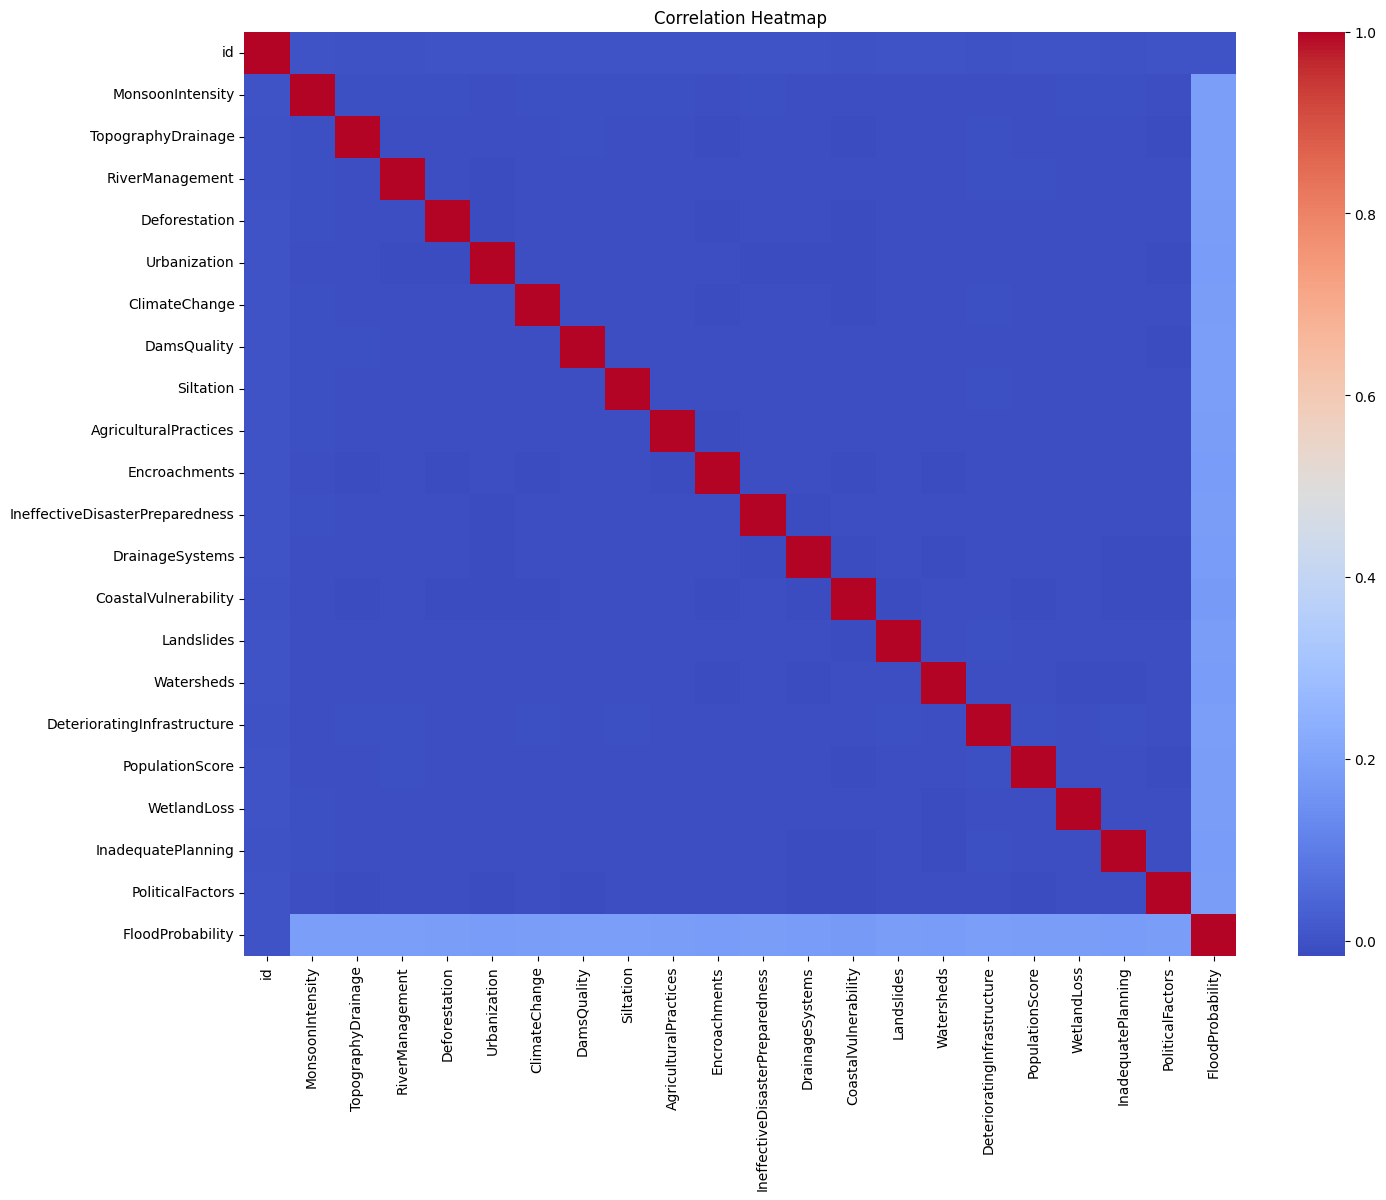

In [12]:
plt.figure(figsize=(16,12))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [13]:
correlation = df.corr()["FloodProbability"].sort_values(ascending=False)

print(correlation)

FloodProbability                   1.000000
DeterioratingInfrastructure        0.190007
MonsoonIntensity                   0.189098
DamsQuality                        0.187996
TopographyDrainage                 0.187635
RiverManagement                    0.187131
Siltation                          0.186789
PopulationScore                    0.185890
Landslides                         0.185346
ClimateChange                      0.184761
Deforestation                      0.184001
WetlandLoss                        0.183396
AgriculturalPractices              0.183366
IneffectiveDisasterPreparedness    0.183109
PoliticalFactors                   0.182417
Watersheds                         0.181907
InadequatePlanning                 0.180968
Urbanization                       0.180861
DrainageSystems                    0.179305
Encroachments                      0.178841
CoastalVulnerability               0.177774
id                                -0.000184
Name: FloodProbability, dtype: f

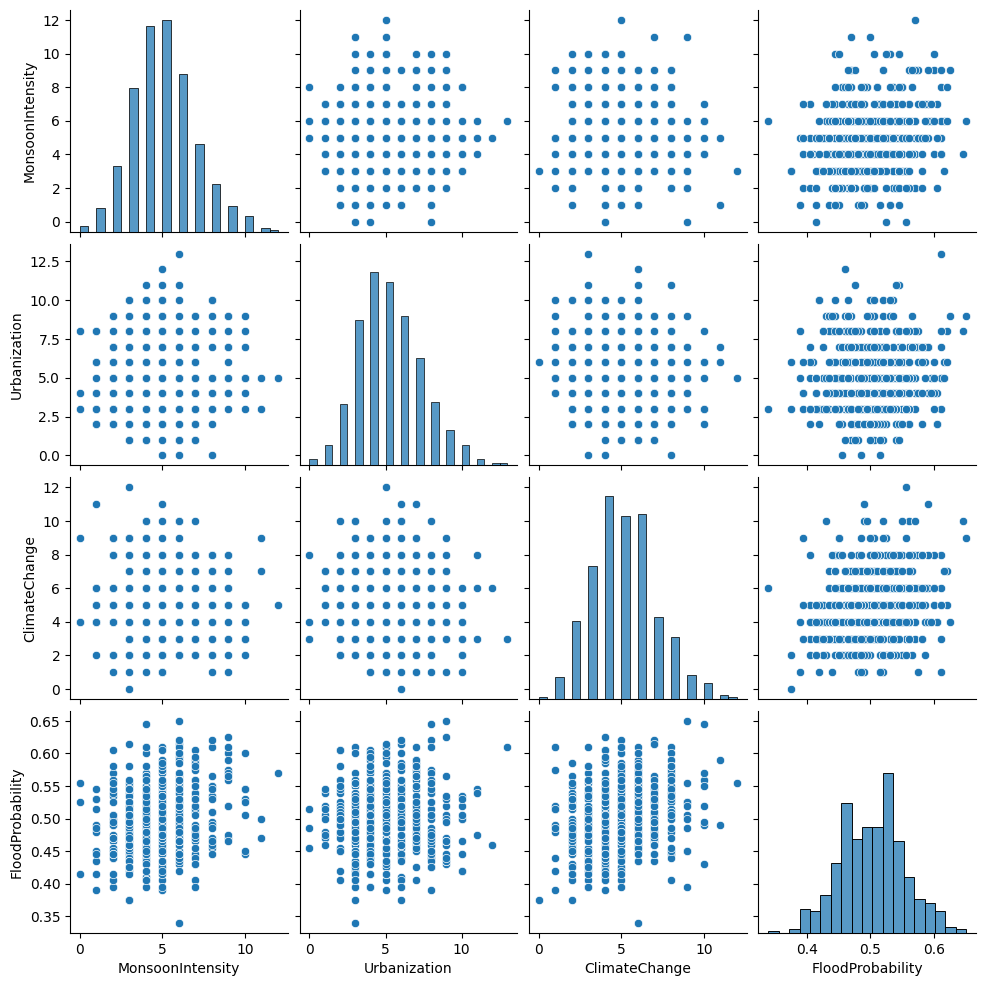

In [14]:
sample = df.sample(500)

sns.pairplot(sample[["MonsoonIntensity",
                     "Urbanization",
                     "ClimateChange",
                     "FloodProbability"]])

plt.show()

In [15]:
# Check missing values in each column

missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
id                                 0
MonsoonIntensity                   0
TopographyDrainage                 0
RiverManagement                    0
Deforestation                      0
Urbanization                       0
ClimateChange                      0
DamsQuality                        0
Siltation                          0
AgriculturalPractices              0
Encroachments                      0
IneffectiveDisasterPreparedness    0
DrainageSystems                    0
CoastalVulnerability               0
Landslides                         0
Watersheds                         0
DeterioratingInfrastructure        0
PopulationScore                    0
WetlandLoss                        0
InadequatePlanning                 0
PoliticalFactors                   0
FloodProbability                   0
dtype: int64


In [16]:
# Check whether any missing values exist

print("Does the dataset contain missing values?")

print(df.isnull().any())

Does the dataset contain missing values?
id                                 False
MonsoonIntensity                   False
TopographyDrainage                 False
RiverManagement                    False
Deforestation                      False
Urbanization                       False
ClimateChange                      False
DamsQuality                        False
Siltation                          False
AgriculturalPractices              False
Encroachments                      False
IneffectiveDisasterPreparedness    False
DrainageSystems                    False
CoastalVulnerability               False
Landslides                         False
Watersheds                         False
DeterioratingInfrastructure        False
PopulationScore                    False
WetlandLoss                        False
InadequatePlanning                 False
PoliticalFactors                   False
FloodProbability                   False
dtype: bool


In [17]:
# Total number of missing values

total_missing = df.isnull().sum().sum()

print("Total Missing Values:", total_missing)

Total Missing Values: 0


In [18]:
# Fill missing values (if any) using column mean

df = df.fillna(df.mean(numeric_only=True))

print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
id                                 0
MonsoonIntensity                   0
TopographyDrainage                 0
RiverManagement                    0
Deforestation                      0
Urbanization                       0
ClimateChange                      0
DamsQuality                        0
Siltation                          0
AgriculturalPractices              0
Encroachments                      0
IneffectiveDisasterPreparedness    0
DrainageSystems                    0
CoastalVulnerability               0
Landslides                         0
Watersheds                         0
DeterioratingInfrastructure        0
PopulationScore                    0
WetlandLoss                        0
InadequatePlanning                 0
PoliticalFactors                   0
FloodProbability                   0
dtype: int64


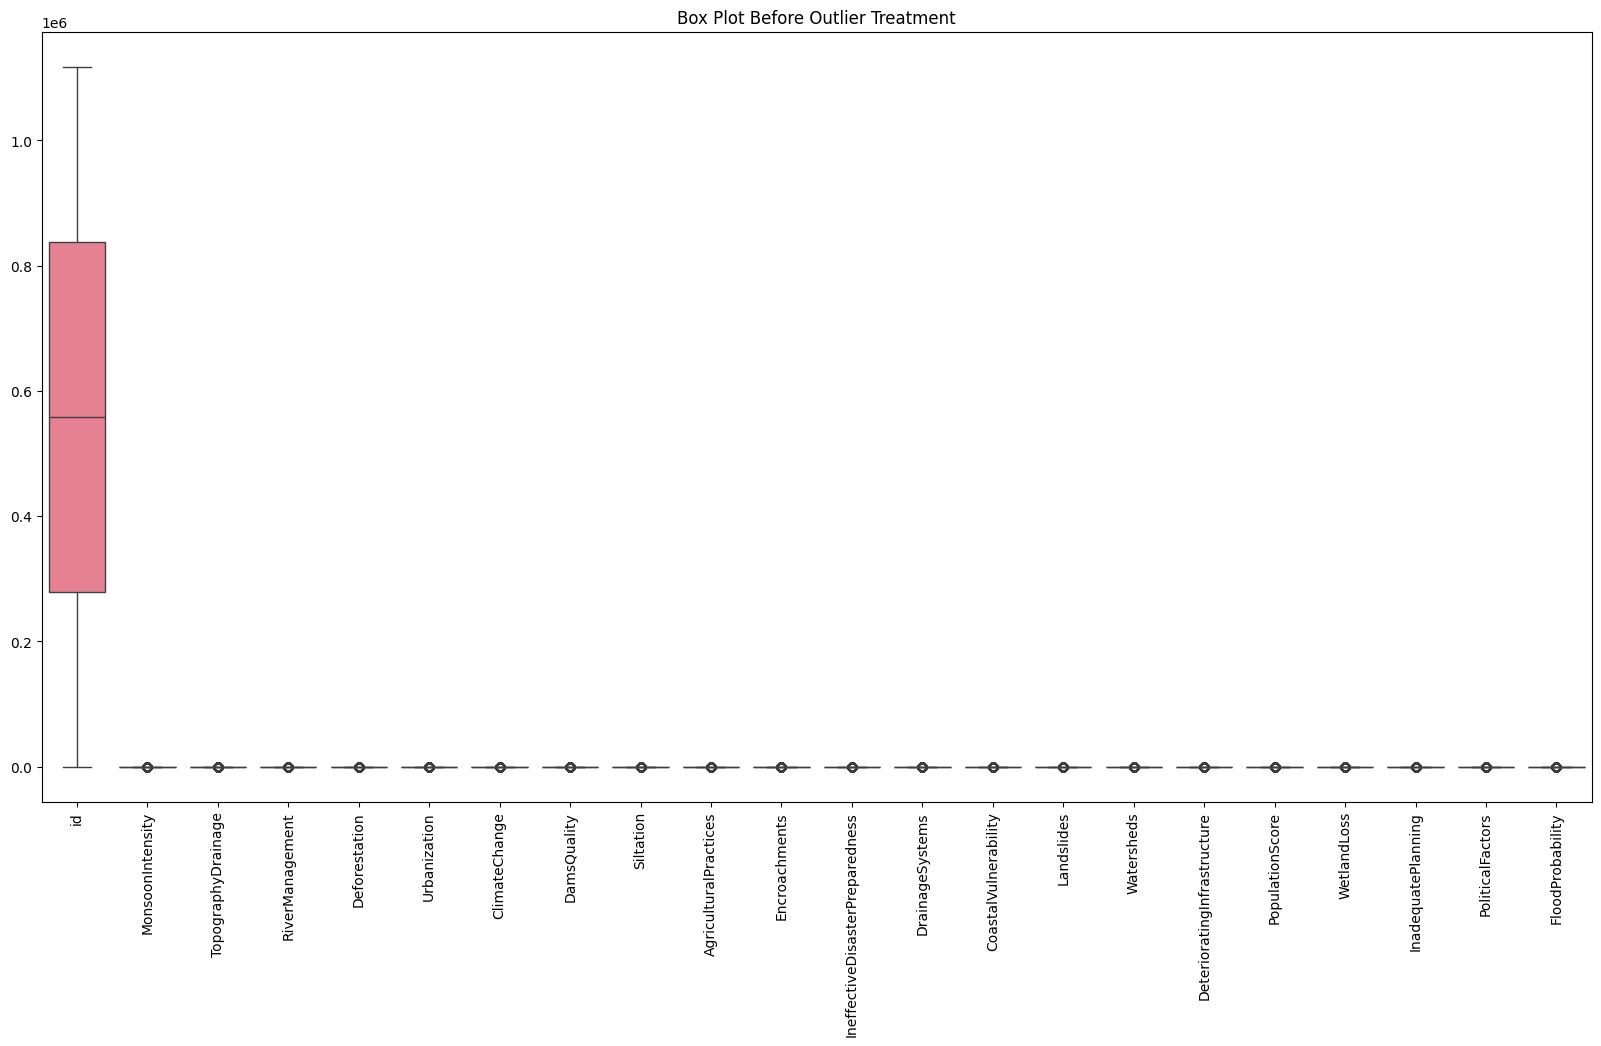

In [19]:
# Box Plot for detecting outliers

plt.figure(figsize=(20,10))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.title("Box Plot Before Outlier Treatment")

plt.show()

In [20]:
# Detect Outliers using IQR

numerical_columns = df.select_dtypes(include=['int64','float64']).columns

for column in numerical_columns:
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_limit) | (df[column] > upper_limit)]

    print(f"{column} : {len(outliers)} Outliers")

id : 0 Outliers
MonsoonIntensity : 9244 Outliers
TopographyDrainage : 9575 Outliers
RiverManagement : 29617 Outliers
Deforestation : 28235 Outliers
Urbanization : 9184 Outliers
ClimateChange : 8702 Outliers
DamsQuality : 31097 Outliers
Siltation : 9079 Outliers
AgriculturalPractices : 9006 Outliers
Encroachments : 31141 Outliers
IneffectiveDisasterPreparedness : 8945 Outliers
DrainageSystems : 30060 Outliers
CoastalVulnerability : 10209 Outliers
Landslides : 8865 Outliers
Watersheds : 9245 Outliers
DeterioratingInfrastructure : 8971 Outliers
PopulationScore : 9290 Outliers
WetlandLoss : 29499 Outliers
InadequatePlanning : 9299 Outliers
PoliticalFactors : 9707 Outliers
FloodProbability : 5579 Outliers


In [21]:
# IQR Based Outlier Capping

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df[column] = df[column].clip(lower_limit, upper_limit)

print("Outliers handled successfully using IQR Capping.")

Outliers handled successfully using IQR Capping.


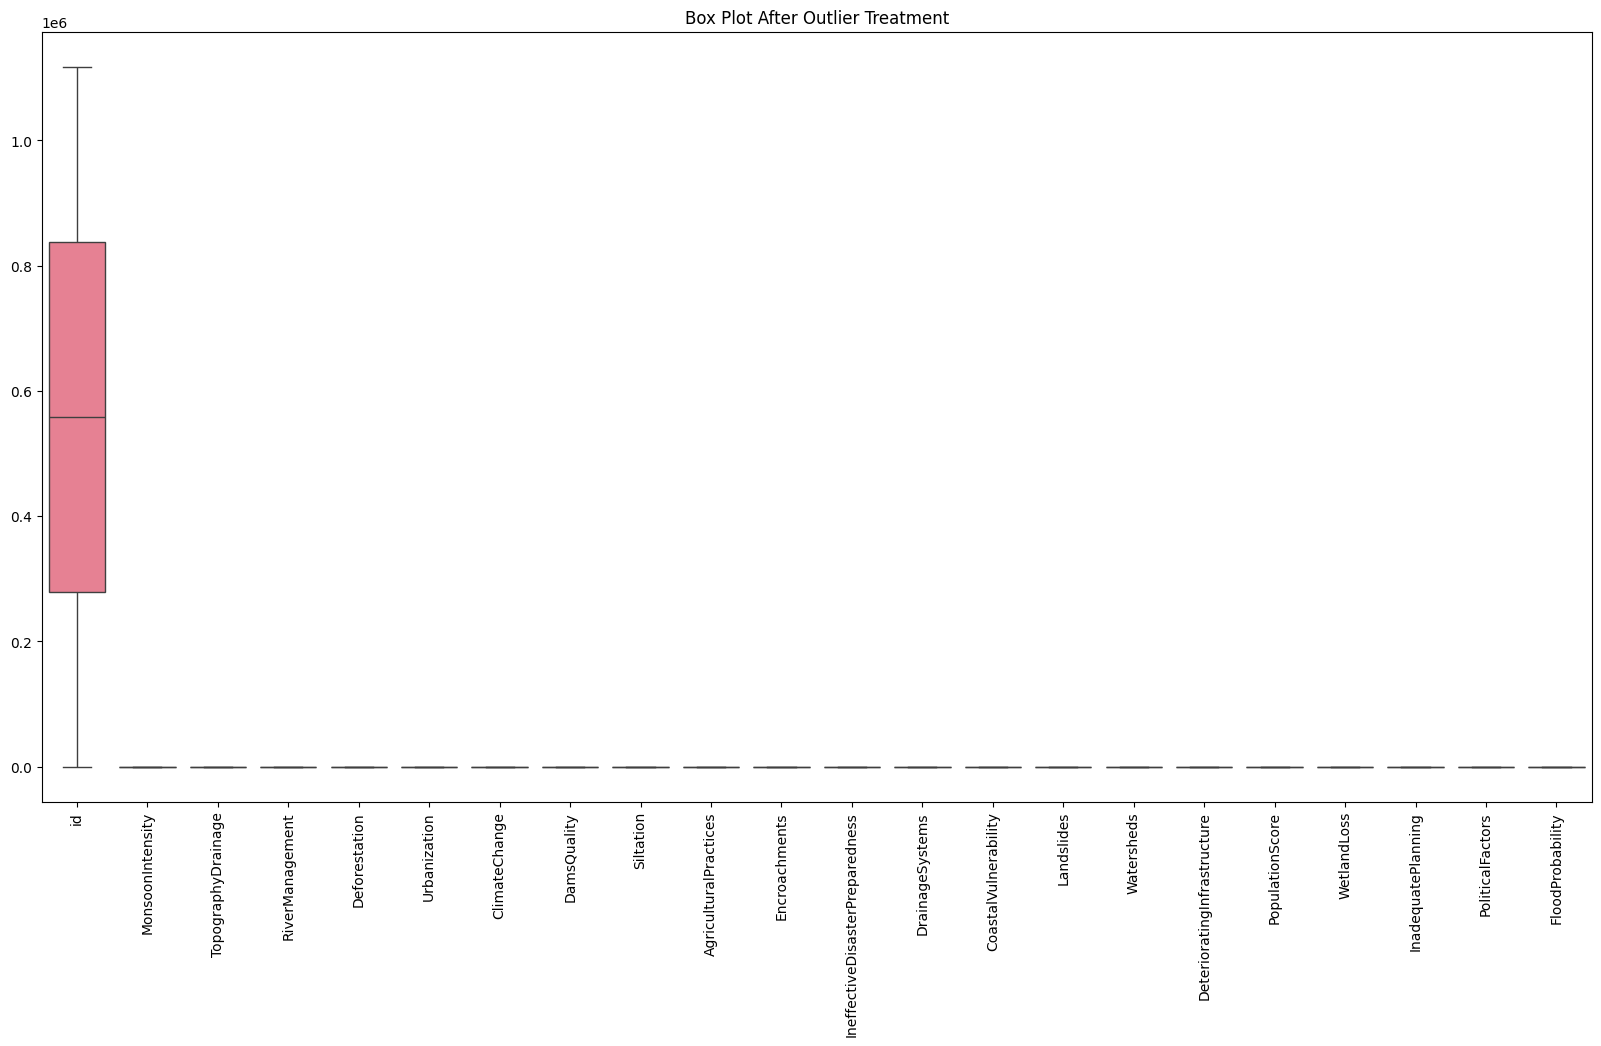

In [22]:
plt.figure(figsize=(20,10))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.title("Box Plot After Outlier Treatment")

plt.show()

In [23]:
# Check the data type of each column

print("Data Types of All Columns:\n")
print(df.dtypes)

Data Types of All Columns:

id                                   int64
MonsoonIntensity                   float64
TopographyDrainage                 float64
RiverManagement                      int64
Deforestation                        int64
Urbanization                       float64
ClimateChange                      float64
DamsQuality                          int64
Siltation                          float64
AgriculturalPractices              float64
Encroachments                        int64
IneffectiveDisasterPreparedness    float64
DrainageSystems                      int64
CoastalVulnerability               float64
Landslides                         float64
Watersheds                         float64
DeterioratingInfrastructure        float64
PopulationScore                    float64
WetlandLoss                          int64
InadequatePlanning                 float64
PoliticalFactors                   float64
FloodProbability                   float64
dtype: object


In [24]:
# Find categorical columns

categorical_columns = df.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(list(categorical_columns))

Categorical Columns:
[]


In [25]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

print("Categorical value handling completed.")

Categorical value handling completed.


In [26]:
print("Updated Data Types:\n")
print(df.dtypes)

Updated Data Types:

id                                   int64
MonsoonIntensity                   float64
TopographyDrainage                 float64
RiverManagement                      int64
Deforestation                        int64
Urbanization                       float64
ClimateChange                      float64
DamsQuality                          int64
Siltation                          float64
AgriculturalPractices              float64
Encroachments                        int64
IneffectiveDisasterPreparedness    float64
DrainageSystems                      int64
CoastalVulnerability               float64
Landslides                         float64
Watersheds                         float64
DeterioratingInfrastructure        float64
PopulationScore                    float64
WetlandLoss                          int64
InadequatePlanning                 float64
PoliticalFactors                   float64
FloodProbability                   float64
dtype: object


In [27]:
# ==============================
# Splitting Features and Target
# ==============================

# Remove 'FloodProbability' from input features
X = df.drop("FloodProbability", axis=1)

# Target variable
y = df["FloodProbability"]

print("Features (X) Shape :", X.shape)
print("Target (y) Shape   :", y.shape)

Features (X) Shape : (1117957, 21)
Target (y) Shape   : (1117957,)


In [28]:
# ==============================
# Train-Test Split
# ==============================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (894365, 21)
Testing Features  : (223592, 21)
Training Labels   : (894365,)
Testing Labels    : (223592,)


In [29]:
# Display first five rows of training data

print("Training Data")

X_train.head()

Training Data


,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,IneffectiveDisasterPreparedness,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors
805665,805665,8.0,7.0,7,6,4.0,3.0,9,8.0,3.0,...,5.0,6,6.0,6.0,5.0,5.0,2.0,6,4.0,7.0
863045,863045,7.0,4.0,4,2,4.0,5.0,7,3.0,6.0,...,2.0,6,5.0,0.0,6.0,2.0,5.0,4,3.0,4.0
496045,496045,6.0,5.0,1,6,6.0,7.0,3,5.0,6.0,...,4.0,5,7.0,6.0,5.0,4.0,9.0,3,5.0,3.0
1079364,1079364,4.0,6.0,6,3,3.0,3.0,1,5.0,4.0,...,7.0,9,6.0,2.0,5.0,4.0,7.0,7,4.0,1.0
191800,191800,6.0,3.0,8,2,7.0,4.0,6,6.0,7.0,...,3.0,5,2.0,6.0,6.0,5.0,5.0,4,4.0,10.0


In [30]:
print("Training Target Values")

y_train.head()

Training Target Values


805665     0.575
863045     0.400
496045     0.505
1079364    0.455
191800     0.535
Name: FloodProbability, dtype: float64

In [31]:
# ====================================
# Import StandardScaler
# ====================================

from sklearn.preprocessing import StandardScaler

In [32]:
# Create StandardScaler Object

scaler = StandardScaler()

print("StandardScaler Created Successfully")

StandardScaler Created Successfully


In [33]:
# ====================================
# Feature Scaling
# ====================================

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed Successfully")

Feature Scaling Completed Successfully


In [34]:
print("Scaled Training Shape :", X_train_scaled.shape)

print("Scaled Testing Shape  :", X_test_scaled.shape)

Scaled Training Shape : (894365, 21)
Scaled Testing Shape  : (223592, 21)


In [35]:
# Convert Scaled Arrays to DataFrame

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

X_train_scaled.head()

,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,IneffectiveDisasterPreparedness,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors
0,0.765009,1.522971,1.007801,1.049753,0.556017,-0.453317,-0.947851,2.059704,1.512561,-0.948160,...,0.030760,0.550284,0.511690,0.524774,0.038269,0.039966,-1.426060,0.548423,-0.454049,1.004495
1,0.942839,1.029865,-0.444823,-0.469744,-1.489806,-0.453317,0.036831,1.048981,-0.940932,0.521462,...,-1.432180,0.550284,0.026099,-2.400064,0.524927,-1.431833,0.039334,-0.466713,-0.941258,-0.450250
2,-0.194552,0.536759,0.039385,-1.989241,0.556017,0.520437,1.021512,-0.972466,0.040465,0.521462,...,-0.456887,0.042601,0.997282,0.524774,0.038269,-0.450634,1.993192,-0.974281,0.033160,-0.935165
3,1.613245,-0.449453,0.523593,0.543254,-0.978350,-0.940194,-0.947851,-1.983189,0.040465,-0.458286,...,1.006053,2.073333,0.511690,-1.425118,0.038269,-0.450634,1.016263,1.055991,-0.454049,-1.904994
4,-1.137455,0.536759,-0.929031,1.556252,-1.489806,1.007314,-0.455510,0.543619,0.531164,1.011336,...,-0.944533,0.042601,-1.430677,0.524774,0.524927,0.039966,0.039334,-0.466713,-0.454049,2.459239


In [36]:
import joblib

joblib.dump(scaler, "../models/scaler.pkl")

print("Scaler Saved Successfully")

Scaler Saved Successfully


In [37]:
print(df["FloodProbability"].head(20))

print("\nMinimum Value:", df["FloodProbability"].min())
print("Maximum Value:", df["FloodProbability"].max())

print("\nUnique Values (first 20):")
print(df["FloodProbability"].unique()[:20])

0     0.445
1     0.450
2     0.530
3     0.535
4     0.415
5     0.440
6     0.460
7     0.595
8     0.505
9     0.455
10    0.515
11    0.480
12    0.470
13    0.510
14    0.485
15    0.430
16    0.525
17    0.515
18    0.560
19    0.555
Name: FloodProbability, dtype: float64

Minimum Value: 0.3649999999999999
Maximum Value: 0.6450000000000001

Unique Values (first 20):
[0.445 0.45  0.53  0.535 0.415 0.44  0.46  0.595 0.505 0.455 0.515 0.48
 0.47  0.51  0.485 0.43  0.525 0.56  0.555 0.49 ]


In [38]:
# =====================================
# Convert Flood Probability to Classes
# =====================================

y_class = (df["FloodProbability"] >= 0.50).astype(int)

print(y_class.value_counts())

print("\nClass Labels")
print("0 = Low Flood Risk")
print("1 = High Flood Risk")

FloodProbability
1    609879
0    508078
Name: count, dtype: int64

Class Labels
0 = Low Flood Risk
1 = High Flood Risk


In [39]:
# Create Features and Target

X = df.drop("FloodProbability", axis=1)

y = y_class

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (894365, 21)
X_test  : (223592, 21)
y_train : (894365,)
y_test  : (223592,)


In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed


In [42]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

print("Decision Tree Classifier Created Successfully")

Decision Tree Classifier Created Successfully


In [43]:
dt_model.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


In [44]:
y_pred_dt = dt_model.predict(X_test)

print("Prediction Completed Successfully")

Prediction Completed Successfully


In [45]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy :", accuracy)

Decision Tree Accuracy : 0.6534223049125192


In [46]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_dt)

print(cm)

[[63147 38244]
 [39248 82953]]


In [47]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.62      0.62      0.62    101391
           1       0.68      0.68      0.68    122201

    accuracy                           0.65    223592
   macro avg       0.65      0.65      0.65    223592
weighted avg       0.65      0.65      0.65    223592



In [48]:
from sklearn.ensemble import RandomForestClassifier

In [49]:
# Create Random Forest Model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

print("Random Forest Model Created Successfully")

Random Forest Model Created Successfully


In [50]:
# Train Random Forest Model

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [51]:
# Predict Test Data

y_pred_rf = rf_model.predict(X_test)

print("Prediction Completed Successfully")

Prediction Completed Successfully


In [52]:
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy :", accuracy)

cm = confusion_matrix(y_test, y_pred_rf)

print("\nConfusion Matrix")

print(cm)

Random Forest Accuracy : 0.7987495080324878

Confusion Matrix
[[79273 22118]
 [22880 99321]]


In [53]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.78      0.78      0.78    101391
           1       0.82      0.81      0.82    122201

    accuracy                           0.80    223592
   macro avg       0.80      0.80      0.80    223592
weighted avg       0.80      0.80      0.80    223592



In [54]:
from sklearn.neighbors import KNeighborsClassifier

In [55]:
# Create KNN Model

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

print("KNN Model Created Successfully")

KNN Model Created Successfully


In [56]:
# Train KNN Model

knn_model.fit(X_train, y_train)

print("KNN Model Trained Successfully")

KNN Model Trained Successfully


In [57]:
# Predict Test Data

y_pred_knn = knn_model.predict(X_test)

print("Prediction Completed Successfully")

Prediction Completed Successfully


In [58]:
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy :", accuracy)

cm = confusion_matrix(y_test, y_pred_knn)

print("\nConfusion Matrix")

print(cm)

KNN Accuracy : 0.7558633582596873

Confusion Matrix
[[77102 24289]
 [30298 91903]]


In [59]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.72      0.76      0.74    101391
           1       0.79      0.75      0.77    122201

    accuracy                           0.76    223592
   macro avg       0.75      0.76      0.75    223592
weighted avg       0.76      0.76      0.76    223592



In [60]:
from xgboost import XGBClassifier

In [61]:
# Create XGBoost Model

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

print("XGBoost Model Created Successfully")

XGBoost Model Created Successfully


In [62]:
# Train XGBoost Model

xgb_model.fit(X_train, y_train)

print("XGBoost Model Trained Successfully")

XGBoost Model Trained Successfully


In [63]:
# Predict Test Data

y_pred_xgb = xgb_model.predict(X_test)

print("Prediction Completed Successfully")

Prediction Completed Successfully


In [64]:
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy :", accuracy)

cm = confusion_matrix(y_test, y_pred_xgb)

print("\nConfusion Matrix")

print(cm)

XGBoost Accuracy : 0.8165810941357472

Confusion Matrix
[[ 80477  20914]
 [ 20097 102104]]


In [65]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.80      0.79      0.80    101391
           1       0.83      0.84      0.83    122201

    accuracy                           0.82    223592
   macro avg       0.82      0.81      0.81    223592
weighted avg       0.82      0.82      0.82    223592



In [66]:
# Compare Model Accuracy

import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "KNN",
        "XGBoost"
    ],
    "Accuracy": [
        0.6534223049125192,
        0.7987495080324878,
        0.7558633582596873,
        0.8165810941357472
    ]
})

comparison

,Model,Accuracy
0,Decision Tree,0.653422
1,Random Forest,0.798750
2,KNN,0.755863
3,XGBoost,0.816581


In [67]:
best_model = comparison.loc[comparison["Accuracy"].idxmax()]

print("Best Model")

print(best_model)

Best Model
Model        XGBoost
Accuracy    0.816581
Name: 3, dtype: object


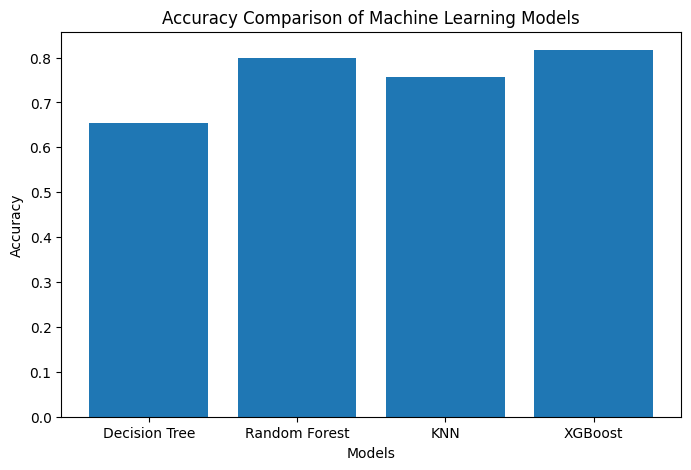

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Accuracy Comparison of Machine Learning Models")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.show()

In [69]:
import joblib
import os

In [70]:
# Create models folder if it does not exist

os.makedirs("../models", exist_ok=True)

print("Models folder is ready.")

Models folder is ready.


In [71]:
# Save XGBoost Model

joblib.dump(xgb_model, "../models/floods.save")

print("XGBoost Model Saved Successfully")

XGBoost Model Saved Successfully


In [72]:
# Save StandardScaler

joblib.dump(scaler, "../models/transform.save")

print("StandardScaler Saved Successfully")

StandardScaler Saved Successfully


In [73]:
import os

print("Files inside models folder:")

print(os.listdir("../models"))

Files inside models folder:
['floods.save', 'scaler.pkl', 'transform.save']


In [74]:
print(X.columns.tolist())

['id', 'MonsoonIntensity', 'TopographyDrainage', 'RiverManagement', 'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality', 'Siltation', 'AgriculturalPractices', 'Encroachments', 'IneffectiveDisasterPreparedness', 'DrainageSystems', 'CoastalVulnerability', 'Landslides', 'Watersheds', 'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss', 'InadequatePlanning', 'PoliticalFactors']
